#### Imports

In [ ]:
# local imports
from dist_gen import * # if not working, move to same directory as target import. This also relied on what is now dist_gen_old

# external imports
import matplotlib as mpl
import matplotlib.style as mplstyle
mplstyle.use('fast')
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
#import plasmapy as plas
#import random as rd
#import sys

In [ ]:
# Add FFmpeg as moviewriter. Install FFmpeg and uncomment the next line if matplotlib.animation throws an error about FFmpeg being missing.
# mpl.rcParams['animation.ffmpeg_path'] = "C:\\Program Files\\FFmpeg\\bin\\ffmpeg.exe" # Common path for Windows

#### 1D Particle Simulation

Parameters/Constants

In [3]:
# Physical Constants

e   = 1.602176634e-19  # elementary charge		(C)
m_e = 9.10938188e-31   # electron mass			(kg)
m_p = 1.67262158e-27   # proton mass			(kg)
k   = 8.987551785972e9 # Coulomb constant		(N*m^2/C^2)
k_B = 1.380649000e-23  # Boltzmann constant 	(J/K)
e_0 = 8.8541878188e-12 # vacuum permittivity	(F/m)

In [4]:
# Initialize and set defaults for and type parameter variables

# Graph/window parameters
x_min:			float =	-2e-11	# window/simulation bounds for position
x_max:			float =	 2e-11
v_min:			float =	-0.025	# window/simulation bounds for velocity
v_max:			float =	 0.025
rho_lim_scale:	float =	 15		# scale of plot relative to greatest magnitude of initial charge density
E_lim_scale:	float =	 20		# ditto for E field
window_res:		int	  =	 250	# resolution used by 2D histograms
ec_lim_margin:	float =	 10		# change log_10 margin from initial for energy conservation plot
# Simulation parameters
dt:				float =	 2e-10	# time step between frames
n_frames:		int	  =	 500	# number of frames to generate
field_res:		int	  =	 500	# resolution used by the simulation to compute charge density and electric field arrays
# Particle counts
N_e:			int	  =	 20000	# number of electrons to simulate
N_i:			int	  =	 20000	# number of ions to simulate

# Computed constants

x_width:  float # width of position sample / window
v_width:  float # width of velocity sample / window
field_dx: float # position increment used for field computations

# Distribution functions

def x_dist(x):
	return np.e**-((30*((x/x_max)-0.25))**2) + np.e**-((30*((x/x_max)+0.25))**2)

def v_dist(v):
	return np.e**-((30*((v/v_max)-0.25))**2) + np.e**-((30*((v/v_max)+0.25))**2)

def x_dist_e(x) -> float:
	return 1

def v_dist_e(v) -> float:
	return np.e**-((30*((v/v_max)-0.25))**2) + np.e**-((30*((v/v_max)+0.25))**2)

def x_dist_i(x) -> float:
	return 1

def v_dist_i(v) -> float:
	return np.e**-((30*((v/v_max)-0.25))**2) + np.e**-((30*((v/v_max)+0.25))**2)

In [5]:
# Fxn to compute dependent constants
def compute_etc_consts():
	global x_width, v_width, field_dx
	x_width = x_max - x_min
	v_width = v_max - v_min
	field_dx = x_width / field_res

# Fxn to set simulation parameters from parameter dictionary
def set_params(inp_params: dict):
	global x_min, x_max, v_min, v_max, rho_lim_scale, E_lim_scale, window_res, ec_lim_margin, dt, n_frames, field_res, N_e, N_i
	global x_dist_e, x_dist_i, v_dist_e, v_dist_i
	valid_keys = {
		"x_min", "x_max", "v_min", "v_max", "rho_lim_scale", "E_lim_scale", "window_res", "ec_lim_margin", "dt", "n_frames", "field_res", "N_e", "N_i", "x_dist_e", "x_dist_i", "v_dist_e", "v_dist_i"
	}
	for key_str, value in inp_params.items():
		if key_str in valid_keys:
			globals()[key_str] = value
	compute_etc_consts()

# Default Simulation Parameters
default_params: dict = {
	"x_min":			-2e-11,
	"x_max":			 2e-11,
	"v_min":			-0.025,
	"v_max":			 0.025,
	"dt":				 2e-10,
	"n_frames":			 500,
	"window_res":		 250,
	"field_res":		 500,
	"rho_lim_scale":	 15,
	"E_lim_scale":		 20,
	"ec_lim_margin":	 10,
	"N_e":				 20000,
	"N_i":				 20000,
	"x_dist_e":			 x_dist_e,
	"v_dist_e":			 v_dist_e,
	"x_dist_i":			 x_dist_i,
	"v_dist_i":			 v_dist_i
}

Particle Definition and Data Handling

In [6]:
# Define default particle params for e- and i+

electron: dict = {
	"name": "e-",
	"charge": -1*e,
	"mass": m_e
}

ion: dict = {
	"name": "i+",
	"charge": 1*e,
	"mass": m_p
}

In [7]:
# initialize/type particle data structs

n_lst: list = []  # particle names
x_lst: list = []  # paricle positions
v_lst: list = []  # particle velocities
a_lst: list = []  # particle accelerations
m_lst: list = []  # particle masses
q_lst: list = []  # particle charges

n_arr:		np.array = 	np.zeros(0,  dtype=str  ) # particle names
x_arr:		np.array = 	np.zeros(0,  dtype=float) # paricle positions
v_arr:		np.array = 	np.zeros(0,  dtype=float) # particle velocities
a_arr:		np.array = 	np.zeros(0,  dtype=float) # particle accelerations
m_arr:		np.array = 	np.zeros(0,  dtype=float) # particle masses
q_arr:		np.array = 	np.zeros(0,  dtype=float) # particle charges

rho_arr:	np.array = 	np.zeros(field_res,  dtype=float) # charge density
E_arr:		np.array = 	np.zeros(field_res,  dtype=float) # electric field

t_arr:		np.array = 	np.zeros(n_frames, dtype=float) # time array for energy display
#K_arr:		np.array = 	np.zeros(n_frames, dtype=float) # total kinetic energy
K_arr_e:	np.array = 	np.zeros(n_frames, dtype=float) # electron kinetic energy
K_arr_i:	np.array = 	np.zeros(n_frames, dtype=float) # ion kinetic energy
U_arr:		np.array = 	np.zeros(n_frames, dtype=float) # electric field potential

e_mask:		np.array = 	np.zeros(0, dtype=bool)
i_mask:		np.array = 	np.zeros(0, dtype=bool)

# set the shape of data arrays

def reinit_data_arrs():
	global n_arr, x_arr, v_arr, a_arr, m_arr, q_arr
	global rho_arr, E_arr
	global t_arr, K_arr_e, K_arr_i, U_arr
	global e_mask, i_mask
	n_arr = 	np.zeros(0,  dtype=str  )  # particle names
	x_arr = 	np.zeros(0,  dtype=float)  # paricle positions
	v_arr = 	np.zeros(0,  dtype=float)  # particle velocities
	a_arr = 	np.zeros(0,  dtype=float)  # particle accelerations
	m_arr = 	np.zeros(0,  dtype=float)  # particle masses
	q_arr = 	np.zeros(0,  dtype=float)  # particle charges

	rho_arr = 	np.zeros(field_res,  dtype=float)  # charge density
	E_arr = 	np.zeros(field_res,  dtype=float)  # electric field

	t_arr = 	np.zeros(n_frames, dtype=float) # time array for energy display
	#K_arr = 	np.zeros(n_frames, dtype=float) # total kinetic energy
	K_arr_e = 	np.zeros(n_frames, dtype=float) # electron kinetic energy
	K_arr_i = 	np.zeros(n_frames, dtype=float) # ion kinetic energy
	U_arr = 	np.zeros(n_frames, dtype=float) # electric field potential

	e_mask = 	np.zeros(0, dtype=bool)
	i_mask = 	np.zeros(0, dtype=bool)

In [8]:
# fxn to add <n> particles of type <particle> to pre-simulation lists based on given distribution fxns and x/v bounds
def add_particles(particle: dict, n: int, xdist: function = x_dist, vdist: function = v_dist, xmin: float = x_min, xmax: float = x_max, vmin: float = v_min, vmax: float = v_max, res = window_res):
	global n_lst, x_lst, v_lst, a_lst, m_lst, q_lst
	for i in range(n):
		n_lst.append(particle["name"])
		x_lst.append(rand_from_dist(xdist, xmin, xmax, res/x_max))
		v_lst.append(rand_from_dist(vdist, vmin, vmax, res/v_max))
		a_lst.append(0)
		m_lst.append(particle["mass"])
		q_lst.append(particle["charge"])
		if i < n and i % 10 == 9:
			print(f"Adding particle {particle["name"]} ({i+1}/{n})", 10*" ", end="\r")
	print(f"Added {n} of {particle["name"]}." + 20*" ")
	
# fxn to write the data from pre-simulation lists to the main simulation arrays for faster computing
def write_to_arrays():
	global n_arr, x_arr, v_arr, a_arr, m_arr, q_arr
	n_arr = np.array(n_lst)
	x_arr = np.array(x_lst)
	v_arr = np.array(v_lst)
	a_arr = np.array(a_lst)
	m_arr = np.array(m_lst)
	q_arr = np.array(q_lst)

# fxn to wipe the pre-simulation lists
def reset_lists():
	global n_lst, x_lst, v_lst, a_lst, m_lst, q_lst, rho_lst, E_lst
	global rho_arr, E_arr, t_arr, K_arr, U_arr
	n_lst = []  # particle names
	x_lst = []  # paricle positions
	v_lst = []  # particle velocities
	a_lst = []  # particle accelerations
	m_lst = []  # particle masses
	q_lst = []  # particle charges

	rho_arr =	np.zeros(field_res,	dtype=float)	# charge density
	E_arr =		np.zeros(field_res,	dtype=float)	# electric field
	t_arr =		np.zeros(n_frames,	dtype=float)	# time array for energy display
	K_arr =		np.zeros(n_frames,	dtype=float)	# total kinetic energy
	U_arr =		np.zeros(n_frames,	dtype=float)	# electric field potential
	print("Arrays reset.")


Simulation Functions

In [9]:
# prefix comp: compute

def comp_a(x = x_arr, m = m_arr, q = q_arr):
	return q * E_at_point(x) / m

def pos_to_field_space(x = x_arr):
	cell_idx = (x - x_min) * field_res / x_width
	return np.clip(cell_idx.astype(int), 0, field_res-1)

def comp_rho():
	idx_arr = pos_to_field_space(x_arr)
	ret_arr = np.zeros_like(rho_arr)
	#for i in range(len(idx_arr)):
	#	ret_arr[idx_arr[i]] += q_arr[i]
	np.add.at(ret_arr, idx_arr, q_arr)
	ret_arr /= field_dx
	return ret_arr

def comp_E(rho = rho_arr): # manually integrate rho to find E
	ret_arr = np.cumsum(rho) * field_dx / e_0
	ret_arr -= np.mean(ret_arr)
	return ret_arr

def E_at_point(x = x_arr): # Find field at some point via interpolation
	cell_idx_pos = (x - x_min) * field_res / x_width
	left_side_idx = np.floor(cell_idx_pos).astype(int)
	right_side_idx = left_side_idx + 1
	tween_pos = cell_idx_pos - left_side_idx
	left_side_idx %= field_res
	right_side_idx %= field_res
	return (1 - tween_pos) * E_arr[left_side_idx] + tween_pos * E_arr[right_side_idx]

def comp_K(v = v_arr, m = m_arr):
	return np.sum((m * v**2)/2)

def comp_U(E = E_arr):
	return (e_0/2) * np.sum(E**2 * field_dx)

In [10]:
# initialize all of the subplots
def init_plots(pix_res = window_res):
	global fig, axs
	fig, axs = plt.subplots(2,3)
	global plot_psh_e, plot_psh_i, plot_vdist_e, plot_vdist_i, plot_rho, plot_E, plot_K_e, plot_K_i, plot_U, plot_energy, plot_err
	fig.set_figwidth(17)
	fig.set_figheight(11)

	# e- phase space
	axs[0][0].set_box_aspect(1)
	axs[0][0].set_xlabel("Position")
	axs[0][0].set_ylabel("Velocity")
	plot_psh_e = axs[0][0].imshow(np.zeros((pix_res, pix_res)), extent=[x_min, x_max, v_min, v_max], origin='lower', aspect="auto")

	# i+ phase space
	axs[0][1].set_box_aspect(1)
	axs[0][1].set_xlabel("Position")
	axs[0][1].set_ylabel("Velocity")
	plot_psh_i = axs[0][1].imshow(np.zeros((pix_res, pix_res)), extent=[x_min, x_max, v_min, v_max], origin='lower', aspect="auto")

	# velocity distributions
	axs[0][2].set_box_aspect(1)
	axs[0][2].set_xlabel("Velocity")
	axs[0][2].set_ylabel("Count")
	plot_vdist_e, = axs[0][2].plot(np.linspace(v_min, v_max, pix_res), np.zeros(pix_res), label = "e-", drawstyle = "steps-mid")
	plot_vdist_i, = axs[0][2].plot(np.linspace(v_min, v_max, pix_res), np.zeros(pix_res), label = "i+", drawstyle = "steps-mid")
	axs[0][2].legend()

	# charge density
	rho_lim = rho_lim_scale * max(abs(rho_arr))
	axs[1][0].set_box_aspect(1)
	axs[1][0].set_xlabel("Position")
	axs[1][0].set_ylabel("Charge Density")
	axs[1][0].set_ylim(-rho_lim, rho_lim)
	plot_rho, = axs[1][0].plot(np.linspace(x_min, x_max, field_res), np.zeros_like(rho_arr), lw = 2)

	# electric field
	axs[1][1].set_box_aspect(1)
	axs[1][1].set_xlabel("Position")
	axs[1][1].set_ylabel("Electric Field")
	axs[1][1].set_ylim(-E_lim_scale * max(abs(E_arr)), E_lim_scale * max(abs(E_arr)))
	plot_E, = axs[1][1].plot(np.linspace(x_min, x_max, field_res), E_arr, lw = 2)

	# energy conservation
	axs[1][2].set_box_aspect(1)
	axs[1][2].set_xlabel("Time")
	axs[1][2].set_ylabel("Total Energy")
	axs[1][2].set_xlim(0, n_frames * dt)
	#k = comp_K(v_arr, m_arr)
	k_e = comp_K(v_arr[e_mask], m_arr[e_mask])
	k_i = comp_K(v_arr[i_mask], m_arr[i_mask])
	u = comp_U(E_arr)
	global init_energy
	init_energy = k_e + k_i + u
	axs[1][2].set_ylim(0.1*np.min([k_e, k_i, u]), 10*np.max([k_e, k_i, u, init_energy]))
	axs[1][2].set_yscale("log")
	init_energy = k_e + k_i + u
	nigh_zero = 1e-30
	plot_energy, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Total Energy", ls = "-.", lw = 3)
	#plot_K_e, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Kinetic Energy", ls = "-.", lw = 3)
	plot_K_e, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Kinetic Energy (e-)", ls = "-", lw = 2)
	plot_K_i, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Kinetic Energy (i+)", ls = "-", lw = 2)
	plot_U, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Field Potential", ls = "-", lw = 2)
	plot_err, = axs[1][2].plot(t_arr, np.full_like(t_arr, nigh_zero), label = "Relative Error", ls = "-", lw = 2)
	axs[1][2].legend()

# plot data onto different axes contained within each frame
def plot_frame(frame, pix_res = window_res):
	global axs, fig
	global e_mask, i_mask
	global plot_psh_e, plot_psh_i, plot_vdist_e, plot_vdist_i, plot_rho, plot_E, plot_K_e, plot_K_i, plot_U, plot_energy, plot_err
	x_e = x_arr[e_mask]
	v_e = v_arr[e_mask]
	x_i = x_arr[i_mask]
	v_i = v_arr[i_mask]
	curr_time = str(float(f'{frame*dt:.9f}'))

	# electron phase space
	axs[0][0].set_title(f"Electron Phase Space (t = {curr_time})")
	data_psh_e, _, _ = np.histogram2d(x_e, v_e, bins = pix_res, range=[[x_min, x_max], [v_min, v_max]])
	plot_psh_e.set_data(data_psh_e.T)
	plot_psh_e.set_clim(0, np.max(data_psh_e))

	# ion phase space
	axs[0][1].set_title(f"Ion Phase Space (t = {curr_time})")
	data_psh_i, _, _ = np.histogram2d(x_i, v_i, bins = pix_res, range=[[x_min, x_max], [v_min, v_max]])
	plot_psh_i.set_data(data_psh_i.T)
	plot_psh_i.set_clim(0, np.max(data_psh_i))

	# particle velocity distributions
	axs[0][2].set_title(f"Particle Distribution (t = {curr_time})")
	data_vdist_e, _ = np.histogram(v_e, bins = pix_res, range=[v_min, v_max])
	data_vdist_i, _ = np.histogram(v_i, bins = pix_res, range=[v_min, v_max])
	if frame == 0:
		max_count = max(np.max(data_vdist_e), np.max(data_vdist_i))
		axs[0][2].set_ylim(0, max_count * 1.1)
	plot_vdist_e.set_ydata(data_vdist_e)
	plot_vdist_i.set_ydata(data_vdist_i)

	# charge density
	axs[1][0].set_title(f"Charge Density (t = {curr_time})")
	plot_rho.set_ydata(rho_arr)

	# electric field
	axs[1][1].set_title(f"Electric Field (t = {curr_time})")
	plot_E.set_ydata(E_arr)

	# energy conservation
	axs[1][2].set_title(f"Energy Conservation (t = {curr_time})")
	T_arr = K_arr_e + K_arr_i + U_arr # K_arr +
	#plot_K.set_data(t_arr[:frame], K_arr_e[:frame])
	plot_K_e.set_data(t_arr[:frame], K_arr_e[:frame])
	plot_K_i.set_data(t_arr[:frame], K_arr_i[:frame])
	plot_U.set_data(t_arr[:frame], U_arr[:frame])
	plot_energy.set_data(t_arr[:frame], T_arr[:frame])
	plot_err.set_data(t_arr[:frame], (np.abs(init_energy - T_arr))[:frame])

def init(N_e, N_i):
	global x_arr, v_arr, a_arr, rho_arr, E_arr, m_arr
	print("Resetting data structures...")
	reset_lists()
	reinit_data_arrs()
	print("Adding particles...")
	add_particles(electron, N_e, x_dist_e, v_dist_e)
	add_particles(ion, N_i, x_dist_i, v_dist_i)
	write_to_arrays()
	print("Particle arrays filled!")
	# create masks to separate particle types using array position
	global e_mask, i_mask
	e_mask = (n_arr == "e-")
	i_mask = (n_arr == "i+")
	# compute initial charge density, electric field and acceleration
	rho_arr = comp_rho()
	E_arr = comp_E(rho_arr)
	a_arr = comp_a(x_arr, m_arr, q_arr)
	print("Computed arrays filled!")
	global fig, axs
	init_plots()
	plot_frame(0)
	print("Plots initialized!")

def step(frame):
	global n_arr, x_arr, v_arr, a_arr, m_arr, q_arr, E_arr, rho_arr
	t_arr[frame] = frame * dt
	#K_arr[frame] = comp_K(v_arr, m_arr)
	K_arr_e[frame] = comp_K(v_arr[e_mask], m_arr[e_mask])
	K_arr_i[frame] = comp_K(v_arr[i_mask], m_arr[i_mask])
	U_arr[frame] = comp_U(E_arr)
	plot_frame(frame)
	x_arr += v_arr * dt + 0.5 * a_arr * dt**2
	x_arr = (x_arr - x_min) % x_width + x_min
	rho_arr = comp_rho()
	E_arr = comp_E(rho_arr)
	a_arr_new = comp_a(x_arr, m_arr, q_arr)
	v_arr += 0.5 * (a_arr + a_arr_new) * dt
	a_arr = a_arr_new
	print("Current frame: " + str(frame + 1), "/", n_frames, 20*" " , end="\r")


Creating an Animation

In [11]:
#init(N_e, N_i)

In [12]:
#ani = anim.FuncAnimation(fig=fig, func=step, frames=n_frames, interval=25)
#ani.save("pic_2stream.gif")

In [17]:
# functions to run the full simulation from .py file
def pic_1d(inp_params: dict = default_params, export_anim_filename: str = ""):
    set_params(inp_params)
    init(N_e, N_i)
    print("Initialization complete! Running simulation...")
    global fig, axs
    if export_anim_filename == "":
        for frame in range(n_frames):
            step(frame)
        fig.show()
    else:
        print("Video export option is enabled. Rendering frames may take some time.")
        ani = anim.FuncAnimation(fig=fig, func=step, frames=n_frames, interval=25)
        ani.save(export_anim_filename)
        

Resetting data structures...
Arrays reset.
Adding particles...
Added 20000 of e-.                         
Added 20000 of i+.                         
Particle arrays filled!
Computed arrays filled!
Plots initialized!
Initialization complete! Running simulation...
Video export option is enabled. Rendering frames may take some time.


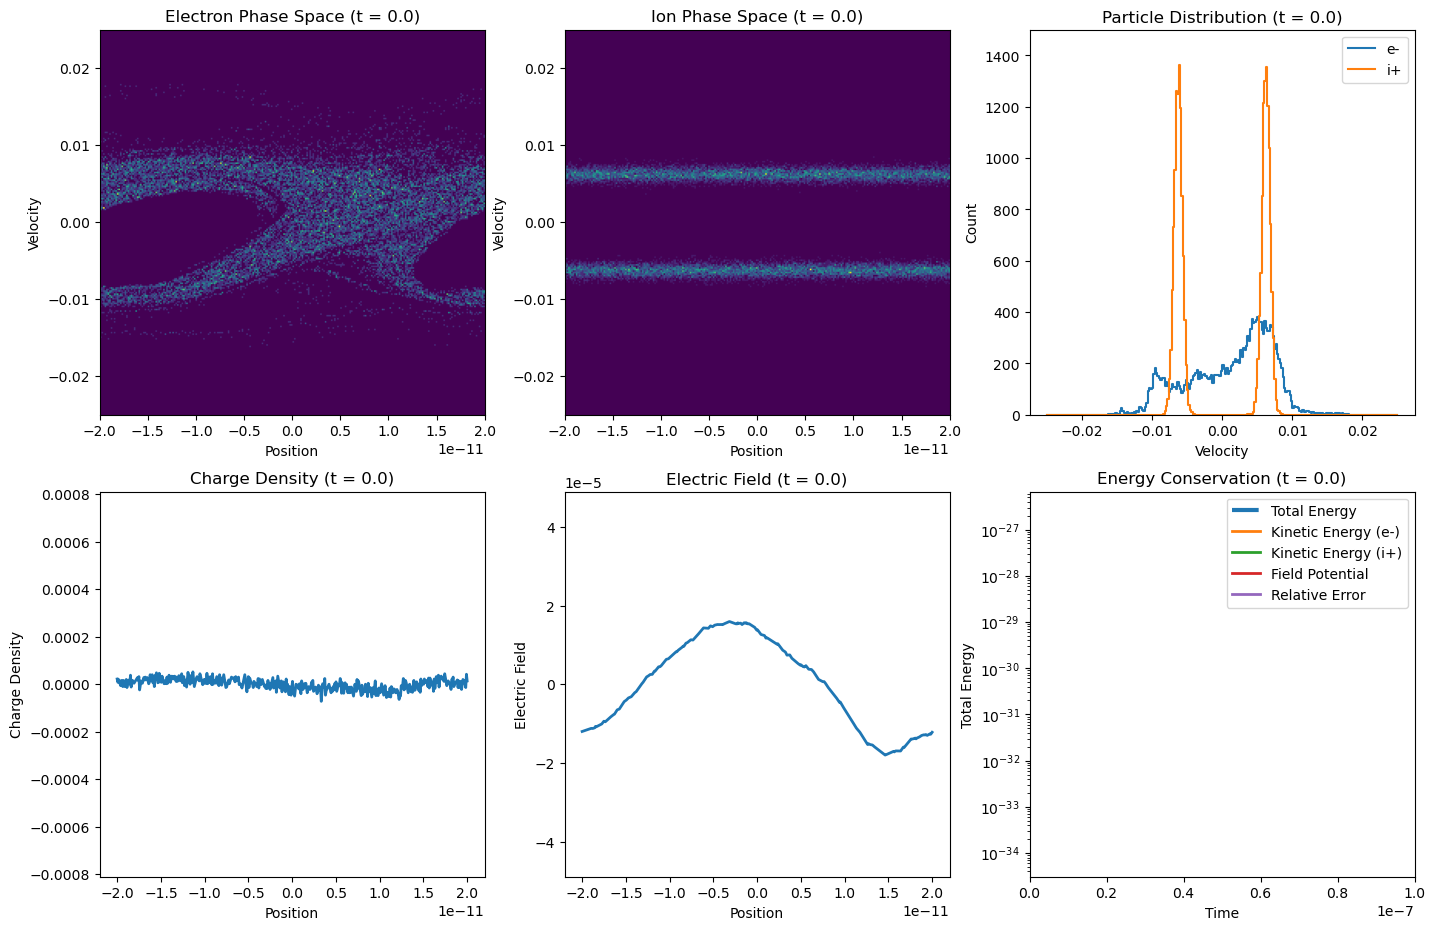

In [19]:
def one(x):
    return 1

modified_params: dict = {
	"x_min":			-2e-11,
	"x_max":			 2e-11,
	"v_min":			-0.025,
	"v_max":			 0.025,
	"dt":				 2e-10,
	"n_frames":			 250,
	"window_res":		 250,
	"field_res":		 500,
	"rho_lim_scale":	 15,
	"E_lim_scale":		 20,
	"ec_lim_margin":	 10,
	"N_e":				 25000,
	"N_i":				 25000,
	"x_dist_e":			 one,
	"v_dist_e":			 one,
	"x_dist_i":			 one,
	"v_dist_i":			 one
}

pic_1d(default_params, "modded_params_test.mp4")